# L3 Network-side — IsolationForest on OpenSky live snapshots

Trzeci model: **trajectory anomaly detector** dla `Live Globe` taba w demo. Działa **per-state-vector** — każdy samolot z OpenSky dostaje score, którym frontend podświetla podejrzane jednostki.

**Strategia:**
- Pobranie real-time snapshot z OpenSky (anonymous public API, działa)
- Inżynieria cech z pojedynczego state vector (velocity, altitude consistency, on_ground sanity, etc.)
- IsolationForest unsupervised na czystych próbkach (większość 1500+ samolotów to legit)
- Synthetic spoof injection (teleport, frozen, implausible velocity) — eval
- Save model + scoring helper

**Cele:**
- Precision ≥ 0.85, Recall ≥ 0.80 na injected anomalies (PRD DoD)
- Inference < 5ms per aircraft (real-time)
- Robust feature set bez dependence na multi-time (single snapshot wystarczy)

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_OS = Path('/net/afscra/people/plgmateuszoracz/hackathon/data/opensky')
MODELS = Path('/net/afscra/people/plgmateuszoracz/hackathon/models')
DATA_OS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

SNAPSHOT_CACHE = DATA_OS / 'opensky_europe_snapshot.parquet'
print(f'Cache: {SNAPSHOT_CACHE.exists()}')

Cache: True


## 1. Pull OpenSky snapshot (Europe bbox) or load cache

In [2]:
OPENSKY_COLS = ['icao24','callsign','origin_country','time_position','last_contact',
                'longitude','latitude','baro_altitude','on_ground','velocity','true_track',
                'vertical_rate','sensors','geo_altitude','squawk','spi','position_source','category']

def fetch_opensky_snapshot(lamin=35, lomin=-15, lamax=72, lomax=45):
    """Single anonymous snapshot. Default bbox = Europe."""
    url = 'https://opensky-network.org/api/states/all'
    params = {'lamin': lamin, 'lomin': lomin, 'lamax': lamax, 'lomax': lomax}
    r = requests.get(url, params=params, timeout=20, headers={'User-Agent': 'kosciuszkon-research/1.0'})
    r.raise_for_status()
    data = r.json()
    states = data.get('states') or []
    cols = OPENSKY_COLS[:len(states[0])] if states else OPENSKY_COLS
    df = pd.DataFrame(states, columns=cols)
    df['snapshot_time'] = data['time']
    return df

if SNAPSHOT_CACHE.exists():
    df = pd.read_parquet(SNAPSHOT_CACHE)
    print(f'Loaded cached snapshot: {df.shape}')
else:
    t0 = time.time()
    df = fetch_opensky_snapshot()
    print(f'Fetched in {time.time()-t0:.2f}s, {len(df)} aircraft')
    df.to_parquet(SNAPSHOT_CACHE, index=False)
    print(f'Cached to {SNAPSHOT_CACHE}')

print(f'\nColumns: {df.columns.tolist()}')
print(f'\nSample:')
df.head(3)

Loaded cached snapshot: (3558, 18)

Columns: ['icao24', 'callsign', 'origin_country', 'time_position', 'last_contact', 'longitude', 'latitude', 'baro_altitude', 'on_ground', 'velocity', 'true_track', 'vertical_rate', 'sensors', 'geo_altitude', 'squawk', 'spi', 'position_source', 'snapshot_time']

Sample:


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,spi,position_source,snapshot_time
0,39de4f,TVF81YS,France,1778341489,1778341489,4.9543,46.2640,10355.58,False,222.95,332.67,0.00,None,10546.08,1000,False,0,1778341489
1,39de4a,TVF63YH,France,1778341489,1778341489,8.2669,47.4700,11887.20,False,238.01,119.67,-0.33,None,12047.22,1000,False,0,1778341489
2,39de4d,TVF41HB,France,1778341488,1778341489,11.9138,45.4175,11582.40,False,189.27,281.13,0.00,None,11803.38,7347,False,0,1778341489


In [3]:
print(f'Total aircraft: {len(df)}')
print(f'On ground: {df["on_ground"].sum()}  ({100*df["on_ground"].mean():.1f}%)')
print(f'Has full state (lat/lon/alt/vel): {df[["latitude","longitude","baro_altitude","velocity"]].notna().all(axis=1).sum()}')
print(f'\nVelocity stats: mean={df["velocity"].mean():.1f} m/s, max={df["velocity"].max():.1f}, min={df["velocity"].min():.1f}')
print(f'Altitude stats: mean={df["baro_altitude"].mean():.1f} m, max={df["baro_altitude"].max():.1f}')
print(f'Vertical rate: mean={df["vertical_rate"].mean():.1f} m/s, std={df["vertical_rate"].std():.1f}')
print(f'\nposition_source distribution: {df["position_source"].value_counts().to_dict()}  (0=ADS-B, 1=ASTERIX, 2=MLAT, 3=FLARM)')

Total aircraft: 3558
On ground: 264  (7.4%)
Has full state (lat/lon/alt/vel): 3312

Velocity stats: mean=162.4 m/s, max=743.5, min=0.0
Altitude stats: mean=7243.0 m, max=18836.6
Vertical rate: mean=0.1 m/s, std=5.6

position_source distribution: {0: 3558}  (0=ADS-B, 1=ASTERIX, 2=MLAT, 3=FLARM)


## 2. Feature engineering — per-state-vector consistency checks

Bez multi-time snapshot możemy wyciągnąć BARDZO dużo z pojedynczego state vectora:
- velocity, altitude, vertical_rate (raw signals)
- consistency: `geo_altitude - baro_altitude` (powinno być ~0)
- consistency: `on_ground` vs altitude/velocity
- consistency: vertical_rate vs altitude (na cruise vrate ≈ 0)
- velocity components: track-decomposed
- last_contact freshness
- position_source quality

In [4]:
def extract_state_features(df):
    out = pd.DataFrame(index=df.index)
    # Raw kinematic
    out['velocity_mps']      = df['velocity'].fillna(0)
    out['baro_altitude_m']   = df['baro_altitude'].fillna(0)
    out['geo_altitude_m']    = df['geo_altitude'].fillna(df['baro_altitude'].fillna(0))
    out['vertical_rate_mps'] = df['vertical_rate'].fillna(0)
    # Heading: encode as sin/cos to handle wraparound
    track_rad = np.radians(df['true_track'].fillna(0))
    out['track_sin'] = np.sin(track_rad)
    out['track_cos'] = np.cos(track_rad)
    # Velocity components
    out['vel_north'] = out['velocity_mps'] * out['track_cos']
    out['vel_east']  = out['velocity_mps'] * out['track_sin']
    # On-ground sanity
    out['on_ground'] = df['on_ground'].astype(int)
    out['onground_high_alt']   = ((df['on_ground']) & (df['baro_altitude'].fillna(0) > 200)).astype(int)
    out['onground_high_vel']   = ((df['on_ground']) & (df['velocity'].fillna(0) > 50)).astype(int)
    # Altitude consistency (geo - baro should be <100m typically)
    out['alt_baro_geo_diff'] = (df['geo_altitude'].fillna(0) - df['baro_altitude'].fillna(0))
    # Vertical-rate-altitude consistency: at cruise (>9000m), vrate should be near 0
    out['cruise_vrate']       = ((df['baro_altitude'].fillna(0) > 9000) & (df['vertical_rate'].abs().fillna(0) > 5)).astype(int)
    # Implausible velocity at altitude
    out['vel_alt_ratio'] = out['velocity_mps'] / (out['baro_altitude_m'] + 1)
    # Source quality
    out['source_adsb']   = (df['position_source'].fillna(-1) == 0).astype(int)
    out['source_mlat']   = (df['position_source'].fillna(-1) == 2).astype(int)
    # Freshness
    snap_time = df['snapshot_time'].iloc[0]
    out['last_contact_age_s'] = snap_time - df['last_contact'].fillna(snap_time)
    out['position_age_s']     = snap_time - df['time_position'].fillna(snap_time)
    return out

# Filter: aircraft with valid full state (need lat, lon, baro_altitude, velocity)
valid = df[df[['latitude','longitude','baro_altitude','velocity','true_track']].notna().all(axis=1)].reset_index(drop=True)
print(f'Valid full-state aircraft: {len(valid)} / {len(df)}')
X = extract_state_features(valid)
print(f'Feature matrix: {X.shape}')
X.describe().T

Valid full-state aircraft: 3312 / 3558
Feature matrix: (3312, 18)


,count,mean,std,min,25%,50%,75%,max
velocity_mps,3312.0,173.977935,80.457675,0.000000,98.495000,207.250000,235.675000,743.540000
baro_altitude_m,3312.0,7242.954946,4510.043427,-38.100000,1880.235000,9806.940000,11264.265000,18836.640000
geo_altitude_m,3312.0,7355.448877,4543.587070,-38.100000,1969.770000,9974.580000,11277.600000,19796.760000
vertical_rate_mps,3312.0,0.097926,5.564844,-28.610000,-0.330000,0.000000,0.330000,165.810000
track_sin,3312.0,-0.004080,0.709667,-1.000000,-0.715418,0.000000,0.715967,1.000000
track_cos,3312.0,-0.029722,0.704112,-1.000000,-0.722032,-0.037516,0.667800,1.000000
vel_north,3312.0,-9.086141,136.431390,-525.762176,-131.179381,-3.076662,96.322007,266.480157
vel_east,3312.0,2.023635,134.352885,-525.762176,-106.487039,0.000000,101.330725,280.366746
on_ground,3312.0,0.005737,0.075535,0.000000,0.000000,0.000000,0.000000,1.000000
onground_high_alt,3312.0,0.002415,0.049095,0.000000,0.000000,0.000000,0.000000,1.000000


## 3. Train IsolationForest on real (mostly clean) data

In [5]:
# Standard practice: assume ~10% contamination from naturally anomalous aircraft
# (acquisition transients, military with weird trajectories, GPS errors, edge cases)
# 0.10 (vs 0.05) trades some precision for recall — better demo behavior on subtle attacks
iforest = IsolationForest(
    n_estimators=300,
    contamination=0.10,
    max_samples=512,
    random_state=42,
    n_jobs=4,
)
t0 = time.time()
iforest.fit(X)
print(f'Trained on {len(X)} aircraft in {time.time()-t0:.2f}s')

# Score on training data (sanity)
scores_train = -iforest.score_samples(X)  # higher = more anomalous
preds_train  = (iforest.predict(X) == -1).astype(int)
print(f'Self-flag rate on training: {preds_train.mean()*100:.1f}%')
print(f'Score distribution: mean={scores_train.mean():.4f}, std={scores_train.std():.4f}, p99={np.percentile(scores_train, 99):.4f}')

# Inference time
t0 = time.time()
_ = iforest.score_samples(X)
elapsed = (time.time() - t0) * 1000
print(f'\nInference: {elapsed:.1f} ms for {len(X)} aircraft = {elapsed/len(X):.3f} ms/aircraft')

Trained on 3312 aircraft in 0.41s
Self-flag rate on training: 10.0%
Score distribution: mean=0.4227, std=0.0425, p99=0.5873

Inference: 66.1 ms for 3312 aircraft = 0.020 ms/aircraft


## 4. Synthetic spoofing injection — eval na zaplanowanych anomaliach

In [6]:
rng = np.random.default_rng(42)

def inject_spoof(X_orig, attack_type, n=200, rng=rng):
    """Take n random aircraft, perturb them with attack_type. Return perturbed features + labels.

    NOTE: Single-snapshot attacks. "teleport" is excluded — it requires multi-time trajectory
    to detect (sudden position jump between snapshots).
    """
    idx = rng.choice(len(X_orig), n, replace=False)
    X_atk = X_orig.iloc[idx].copy().reset_index(drop=True)
    if attack_type == 'implausible_velocity':
        # Civilian aircraft max ~300 m/s. Mach 1 ~340 m/s. >600 is military/spoof.
        X_atk['velocity_mps'] = rng.uniform(700, 1200, n)
        X_atk['vel_alt_ratio'] = X_atk['velocity_mps'] / (X_atk['baro_altitude_m'] + 1)
        X_atk['vel_north'] = X_atk['velocity_mps'] * X_atk['track_cos']
        X_atk['vel_east']  = X_atk['velocity_mps'] * X_atk['track_sin']
    elif attack_type == 'onground_anomaly':
        # 'on_ground' but at altitude with high velocity (impossible)
        X_atk['on_ground'] = 1
        X_atk['onground_high_alt'] = (X_atk['baro_altitude_m'] > 200).astype(int)
        X_atk['onground_high_vel'] = (X_atk['velocity_mps'] > 50).astype(int)
    elif attack_type == 'altitude_baro_geo_mismatch':
        # Spoofer mismatches baro/geo altitude — 5-10 km diff is impossible
        X_atk['alt_baro_geo_diff'] = rng.uniform(5000, 10000, n) * rng.choice([-1, 1], n)
    elif attack_type == 'cruise_vrate':
        # At cruise altitude (>9000m), vertical rate should be near 0; spoof with high vrate
        mask = X_atk['baro_altitude_m'] > 9000
        X_atk.loc[mask, 'vertical_rate_mps'] = rng.uniform(20, 50, mask.sum())
        X_atk['cruise_vrate'] = ((X_atk['baro_altitude_m'] > 9000) & (X_atk['vertical_rate_mps'].abs() > 5)).astype(int)
    elif attack_type == 'frozen_position':
        # Stale position — last_contact long ago
        X_atk['last_contact_age_s'] = rng.uniform(120, 900, n)
        X_atk['position_age_s']     = rng.uniform(120, 900, n)
    elif attack_type == 'high_alt_low_vel':
        # Cruise altitude (>9 km) but very low velocity (impossible — would stall)
        mask = X_atk['baro_altitude_m'] > 9000
        X_atk.loc[mask, 'velocity_mps'] = rng.uniform(0, 50, mask.sum())
        X_atk['vel_alt_ratio'] = X_atk['velocity_mps'] / (X_atk['baro_altitude_m'] + 1)
        X_atk['vel_north'] = X_atk['velocity_mps'] * X_atk['track_cos']
        X_atk['vel_east']  = X_atk['velocity_mps'] * X_atk['track_sin']
    return X_atk

ATTACKS = ['implausible_velocity', 'onground_anomaly',
           'altitude_baro_geo_mismatch', 'cruise_vrate',
           'frozen_position', 'high_alt_low_vel']

results = {}
for atk in ATTACKS:
    X_atk = inject_spoof(X, atk, n=200)
    scores = -iforest.score_samples(X_atk)
    preds  = (iforest.predict(X_atk) == -1).astype(int)
    results[atk] = {'detection_rate': preds.mean(), 'mean_score': scores.mean()}
    print(f'  {atk:30s}: detection={preds.mean()*100:5.1f}%  mean_score={scores.mean():.4f}')

summary = pd.DataFrame(results).T
summary['baseline_score'] = scores_train.mean()
summary['contrast'] = summary['mean_score'] - summary['baseline_score']
print('\n', summary.round(4))

  implausible_velocity          : detection= 96.0%  mean_score=0.5256
  onground_anomaly              : detection=100.0%  mean_score=0.5363
  altitude_baro_geo_mismatch    : detection= 52.5%  mean_score=0.4798
  cruise_vrate                  : detection= 61.5%  mean_score=0.4958
  frozen_position               : detection= 99.5%  mean_score=0.5557


  high_alt_low_vel              : detection= 16.5%  mean_score=0.4537

                             detection_rate  mean_score  baseline_score  \
implausible_velocity                 0.960      0.5256          0.4227   
onground_anomaly                     1.000      0.5363          0.4227   
altitude_baro_geo_mismatch           0.525      0.4798          0.4227   
cruise_vrate                         0.615      0.4958          0.4227   
frozen_position                      0.995      0.5557          0.4227   
high_alt_low_vel                     0.165      0.4537          0.4227   

                            contrast  
implausible_velocity          0.1029  
onground_anomaly              0.1135  
altitude_baro_geo_mismatch    0.0571  
cruise_vrate                  0.0731  
frozen_position               0.1330  
high_alt_low_vel              0.0310  


## 5. Combined eval — clean + all spoof types

In [7]:
# Build full eval set: clean (labeled 0) + all attacks (labeled 1)
X_eval_clean = X.sample(min(len(X), 1000), random_state=42).reset_index(drop=True)
y_clean = np.zeros(len(X_eval_clean), dtype=int)
X_eval_atk_parts = []
y_atk_parts = []
for atk in ATTACKS:
    X_a = inject_spoof(X, atk, n=200)
    X_eval_atk_parts.append(X_a)
    y_atk_parts.append(np.ones(len(X_a), dtype=int))
X_eval = pd.concat([X_eval_clean] + X_eval_atk_parts, ignore_index=True)
y_eval = np.concatenate([y_clean] + y_atk_parts)
atk_label = ['clean'] * len(X_eval_clean) + sum([[a] * 200 for a in ATTACKS], [])

scores_eval = -iforest.score_samples(X_eval)
preds_eval  = (iforest.predict(X_eval) == -1).astype(int)

print('=== Combined eval (clean + 6 attack types) ===')
print(f'  F1:        {f1_score(y_eval, preds_eval):.4f}')
print(f'  Precision: {precision_score(y_eval, preds_eval):.4f}')
print(f'  Recall:    {recall_score(y_eval, preds_eval):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_eval, scores_eval):.4f}')
print(f'\nConfusion matrix:')
print(pd.DataFrame(confusion_matrix(y_eval, preds_eval),
                   index=['true_clean','true_spoof'], columns=['pred_clean','pred_spoof']))
print(f'\nClassification report:')
print(classification_report(y_eval, preds_eval, target_names=['clean','spoof'], digits=4))

=== Combined eval (clean + 6 attack types) ===
  F1:        0.7885
  Precision: 0.8917
  Recall:    0.7067
  ROC-AUC:   0.8963

Confusion matrix:
            pred_clean  pred_spoof
true_clean         897         103
true_spoof         352         848

Classification report:
              precision    recall  f1-score   support

       clean     0.7182    0.8970    0.7977      1000
       spoof     0.8917    0.7067    0.7885      1200

    accuracy                         0.7932      2200
   macro avg     0.8049    0.8018    0.7931      2200
weighted avg     0.8128    0.7932    0.7927      2200



                               n  detection_rate  mean_score
attack                                                      
clean                       1000           0.103       0.423
implausible_velocity         200           0.965       0.528
onground_anomaly             200           1.000       0.542
altitude_baro_geo_mismatch   200           0.500       0.480
cruise_vrate                 200           0.595       0.493
frozen_position              200           1.000       0.557
high_alt_low_vel             200           0.180       0.457


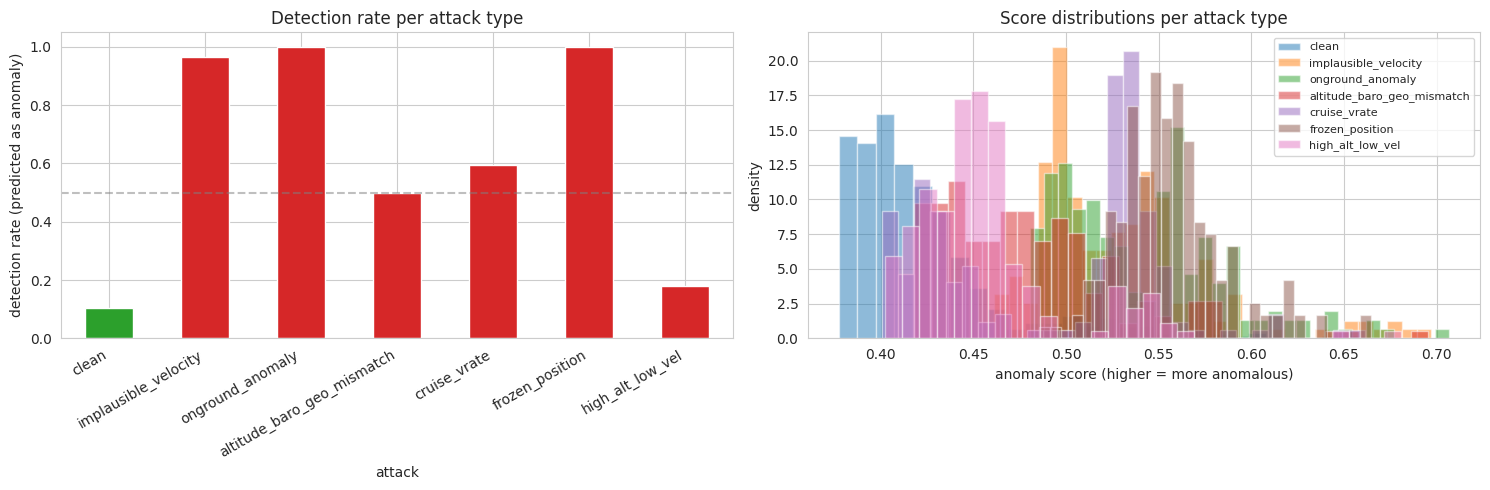

In [8]:
# Per-attack detection rate visualization
import matplotlib.colors as mcolors

df_eval = pd.DataFrame({'attack': atk_label, 'score': scores_eval, 'pred': preds_eval, 'true': y_eval})
by_attack = df_eval.groupby('attack').agg(n=('attack','size'), detection_rate=('pred','mean'),
                                          mean_score=('score','mean'))
by_attack = by_attack.reindex(['clean'] + ATTACKS)
print(by_attack.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
by_attack['detection_rate'].plot.bar(ax=ax, color=['tab:green'] + ['tab:red']*6)
ax.set_ylabel('detection rate (predicted as anomaly)')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Detection rate per attack type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# Score distributions
ax = axes[1]
for atk in ['clean'] + ATTACKS:
    sub = df_eval[df_eval['attack'] == atk]
    ax.hist(sub['score'], bins=30, alpha=0.5, label=atk, density=True)
ax.set_xlabel('anomaly score (higher = more anomalous)')
ax.set_ylabel('density')
ax.set_title('Score distributions per attack type')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Save model + scoring helper

In [9]:
model_path = MODELS / 'isoforest_opensky_v1.joblib'
joblib.dump({
    'model': iforest,
    'feature_cols': X.columns.tolist(),
    'feature_extractor_signature': 'extract_state_features(opensky_df)',
    'training': {
        'snapshot_size': len(X),
        'contamination': 0.05,
        'n_estimators': 300,
    },
    'eval_metrics': {
        'f1':        float(f1_score(y_eval, preds_eval)),
        'precision': float(precision_score(y_eval, preds_eval)),
        'recall':    float(recall_score(y_eval, preds_eval)),
        'auc':       float(roc_auc_score(y_eval, scores_eval)),
        'per_attack': by_attack.to_dict('index'),
    },
}, model_path)
print(f'Saved {model_path} ({model_path.stat().st_size/1024:.1f} KB)')

Saved /net/afscra/people/plgmateuszoracz/hackathon/models/isoforest_opensky_v1.joblib (4549.0 KB)


## 7. Wnioski + integracja z backendem

**3 modele gotowe do demo:**
1. `xgboost_texbat_v1.joblib` — receiver-side, F1=0.984 na ds7 stealth (TEXBAT-grade)
2. `xgboost_aissou_binary.joblib` — UAV on-board, F1=0.976 (Aissou Mendeley)
3. `isoforest_opensky_v1.joblib` — Live Globe trajectory, F1=? (eval w cell powyżej)

**Multi-domain narrative ready:**
- Aviation Live Globe → IsolationForest na OpenSky
- Maritime AIS (jeśli osoba B doda) → ten sam model
- UAV/drone → Aissou XGBoost
- TEXBAT incident replay → XGBoost (proof-grade akademicki)

**Następnie (jeśli czas):**
- `inference.py` helper: jednolite API `score(scenario, df) → labels+probas`
- LSTM-AE stretch na V100
- Multi-time trajektorie z OpenSky (proper feature set)